# Deep Learning Models for Bridge Deck Evaluation Using Impact Echo

**Reproduction of the 2020 research by Sattar Dorafshan and Hoda Azari**

Article: https://doi.org/10.1016/j.conbuildmat.2020.120109<br>
Dataset: https://data.mendeley.com/datasets/44rb96872r/1

## Project Overview
This notebook reproduces the data processing and deep learning pipeline to autonomously classify raw 1D Impact Echo (IE) signals into two categories: sound concrete (Class 0) and defected concrete (Class 1). 

---

## Abstract
Impact echo (IE) is a common nondestructive evaluation (NDE) method to detect subsurface defects in concrete bridge decks. The conventional approach for analyzing the IE data requires user expertise to define analysis parameters that could hinder broad field implementation. In this paper, the feasibility of using deep learning models (DLMs) for autonomous subsurface defect detection in bridge decks using IE has been investigated. A set of eight laboratory-made reinforced concrete bridge specimens with artificial defects were constructed at the Federal Highway Administration Advanced Sensing Technology NDE laboratory. A total number of 2016 of IE data was collected from these specimens. A one-dimensional (1D) convolutional neural network (CNN), and a 1D recurrent neural network using bidirectional longshort term memory units, were developed and applied on the IE data. In addition, two-dimensional (2D) world renowned CNNs were applied on the 2D representatives of the IE data, i.e., spectrograms. The proposed 1D CNN was the most accurate model. The proposed 1DCNN was superior to previous machine learning models that were previously used for IE classification. The results of this study showed the feasibility and the potentials of the DLMs for subsurface defect detection.

In [7]:
# Standard Data Science & Manipulation Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Signal Processing
from scipy.fft import fft, fftfreq
from scipy import signal

# Set plotting style
sns.set_theme(style="whitegrid")

## Data Loading & Exploration

Before feeding the Impact Echo (IE) data into our deep learning models, we need to understand its raw structure. 

The raw IE files (e.g., `F-24.txt`, `F-28.txt`) are stored as text files containing exactly 2,000 data points per signal. Each file is structured with two columns of exponential floats:
* **Time (s)**
* **Voltage (V)**

In the following cell, we will load and parse these text files into manageable arrays for our pipeline, allowing us to visualize the raw waveforms and their frequency responses.

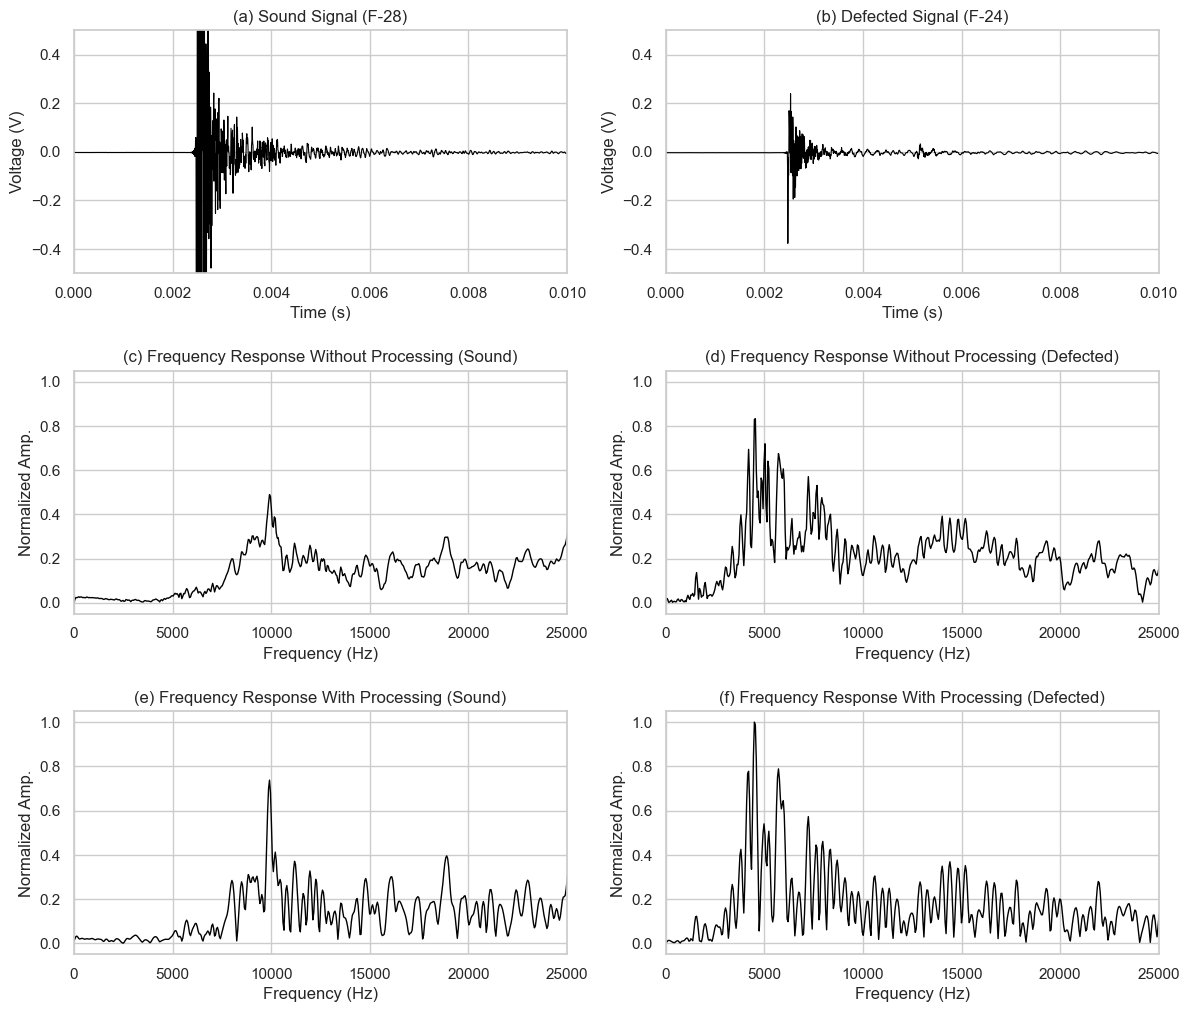

In [8]:
# Define the file paths
sound_file = r"C:\Users\kairen.shen.ctr\My Drive\4 IE reproduce\testing data\Slab1\S\F-28.txt"
defected_file = r"C:\Users\kairen.shen.ctr\My Drive\4 IE reproduce\testing data\Slab1\D\F-24.txt"

# Helper function to load data
def load_ie_signal(filepath):
    # The files contain two columns without headers
    df = pd.read_csv(filepath, sep=r'\s+', header=None, names=['Time', 'Voltage'])
    return df['Time'].values, df['Voltage'].values

# Load the signals
t_sound, v_sound = load_ie_signal(sound_file)
t_defected, v_defected = load_ie_signal(defected_file)

# Signal Parameters
fs = 200000  # Sampling frequency: 200 kHz
N = len(v_sound) # 2000 data points
N_fft = 4096     # Zero-padding for a smoother frequency curve

# Frequency calculations
xf = fftfreq(N_fft, 1/fs)[:N_fft//2]  # Get positive frequencies only

# Helper function to compute normalized FFT
def compute_normalized_fft(voltage_signal, apply_window=False):
    # Remove the DC offset (mean) so 0 Hz doesn't dominate the plot
    voltage_signal = voltage_signal - np.mean(voltage_signal)
    
    if apply_window:
        # Apply a time-domain Blackman-Harris window to reduce spectral leakage
        window = signal.windows.blackmanharris(N)
        voltage_signal = voltage_signal * window
        
    # Compute FFT with zero-padding
    yf = fft(voltage_signal, n=N_fft)
    yf_abs = np.abs(yf[:N_fft//2])
    
    # Normalize amplitude
    yf_norm = yf_abs / np.max(yf_abs)
    return yf_norm

# Calculate FFTs (Unfiltered)
yf_sound_raw = compute_normalized_fft(v_sound, apply_window=False)
yf_defected_raw = compute_normalized_fft(v_defected, apply_window=False)

# Calculate FFTs (Windowed with Blackman-Harris)
yf_sound_filtered = compute_normalized_fft(v_sound, apply_window=True)
yf_defected_filtered = compute_normalized_fft(v_defected, apply_window=True)

# Plotting Figure 2
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
plt.subplots_adjust(hspace=0.4)

# (a) Sound Signal (Time Domain)
axs[0, 0].plot(t_sound, v_sound, color='black', linewidth=0.8)
axs[0, 0].set_title('(a) Sound Signal (F-28)')
axs[0, 0].set_xlabel('Time (s)')
axs[0, 0].set_ylabel('Voltage (V)')
axs[0, 0].set_xlim(0, 0.01)
axs[0, 0].set_ylim(-0.5, 0.5)

# (b) Defected Signal (Time Domain)
axs[0, 1].plot(t_defected, v_defected, color='black', linewidth=0.8)
axs[0, 1].set_title('(b) Defected Signal (F-24)')
axs[0, 1].set_xlabel('Time (s)')
axs[0, 1].set_ylabel('Voltage (V)')
axs[0, 1].set_xlim(0, 0.01)
axs[0, 1].set_ylim(-0.5, 0.5)

# (c) Sound Signal Frequency Response (Unprocessed)
axs[1, 0].plot(xf, yf_sound_raw, color='black', linewidth=1)
axs[1, 0].set_title('(c) Frequency Response Without Processing (Sound)')
axs[1, 0].set_xlabel('Frequency (Hz)')
axs[1, 0].set_ylabel('Normalized Amp.')
axs[1, 0].set_xlim(0, 25000)

# (d) Defected Signal Frequency Response (Unprocessed)
axs[1, 1].plot(xf, yf_defected_raw, color='black', linewidth=1)
axs[1, 1].set_title('(d) Frequency Response Without Processing (Defected)')
axs[1, 1].set_xlabel('Frequency (Hz)')
axs[1, 1].set_ylabel('Normalized Amp.')
axs[1, 1].set_xlim(0, 25000)

# (e) Sound Signal Frequency Response (Windowed + Smoothed)
axs[2, 0].plot(xf, yf_sound_filtered, color='black', linewidth=1)
axs[2, 0].set_title('(e) Frequency Response With Processing (Sound)')
axs[2, 0].set_xlabel('Frequency (Hz)')
axs[2, 0].set_ylabel('Normalized Amp.')
axs[2, 0].set_xlim(0, 25000)

# (f) Defected Signal Frequency Response (Windowed + Smoothed)
axs[2, 1].plot(xf, yf_defected_filtered, color='black', linewidth=1)
axs[2, 1].set_title('(f) Frequency Response With Processing (Defected)')
axs[2, 1].set_xlabel('Frequency (Hz)')
axs[2, 1].set_ylabel('Normalized Amp.')
axs[2, 1].set_xlim(0, 25000)

plt.show()

## Signal Characteristics

As illustrated in the above figure (similiar to Figure 2 of the original paper), there is a distinct difference between the mechanical response of intact concrete and delaminated concrete when struck by the impactor. While our Deep Learning models will process the raw time-domain (Time/Voltage) data, the physical differences manifest clearly:

Class S (Sound Concrete): The impact generates stress waves that travel through the full thickness (0.2 m) of the deck and reflect off the solid bottom. In the time domain (our Voltage column), this often appears as a clean, exponentially decaying waveform. In traditional frequency analysis, this produces a single, sharp, high-amplitude peak (the thickness mode frequency).

Class D (Defected Concrete): When a defect (like a shallow or deep delamination) is present, the stress waves reflect off the flaw rather than the bottom of the deck. This causes the thin layer of concrete above the defect to oscillate in a "flexural mode." In our time-domain data, this causes irregular ringing, altered attenuation, or a shift in the signal's energy. Traditionally, this results in lower-frequency peaks or multiple dispersed peaks with lower amplitudes.